In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e7/train.csv
/kaggle/input/competitions/playground-series-s6e7/test.csv


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import os
os.listdir("/kaggle/input/competitions/playground-series-s6e7")

['sample_submission.csv', 'train.csv', 'test.csv']

In [4]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/test.csv")

In [5]:
train.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

In [7]:
train.isnull().sum()

id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

In [8]:
train.shape

(690088, 15)

In [9]:
train.columns

Index(['id', 'health_condition', 'sleep_duration', 'heart_rate', 'bmi',
       'calorie_expenditure', 'step_count', 'exercise_duration',
       'water_intake', 'diet_type', 'stress_level', 'sleep_quality',
       'physical_activity_level', 'smoking_alcohol', 'gender'],
      dtype='object')

In [10]:
numerical_columns = train.select_dtypes( include =["int64" , "float64"]).columns
numerical_columns = numerical_columns.drop("id")
for col in numerical_columns:
    train[col] = train[col].fillna(train[col].median())
    

In [11]:
cat_columns = train.select_dtypes( include = ["object"]).columns
for col in cat_columns:
    if not train[col].mode().empty:
        train[col] = train[col].fillna(train[col].mode().iloc[0])
    else:
        train[col] = train[col].fillna("Unknown")

In [12]:
train.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,medium,average,sedentary,yes,male


In [13]:
train.isnull().sum()

id                         0
health_condition           0
sleep_duration             0
heart_rate                 0
bmi                        0
calorie_expenditure        0
step_count                 0
exercise_duration          0
water_intake               0
diet_type                  0
stress_level               0
sleep_quality              0
physical_activity_level    0
smoking_alcohol            0
gender                     0
dtype: int64

In [14]:
train.duplicated().sum()

np.int64(0)

In [15]:
train["health_condition"].value_counts(normalize=True)

health_condition
at-risk      0.858675
unhealthy    0.083647
fit          0.057678
Name: proportion, dtype: float64

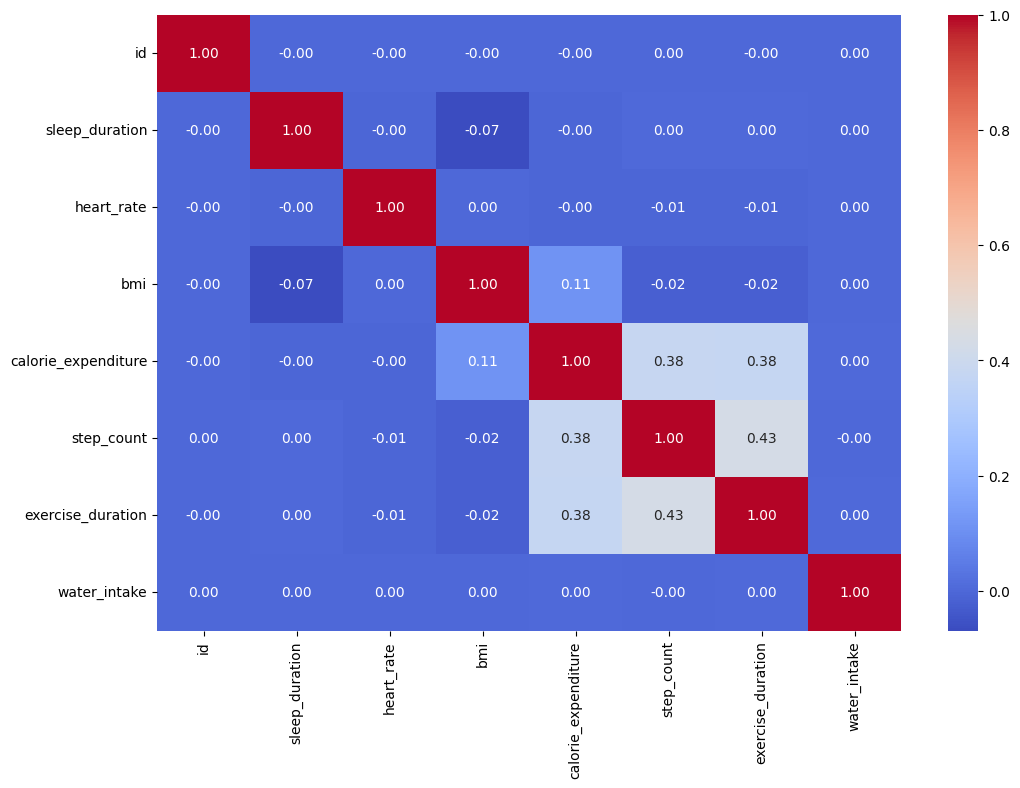

In [16]:
num_data = train.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12, 8))
sns.heatmap(num_data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [17]:
cat_cols = train.select_dtypes(include="object").columns

for col in cat_cols:
    print(col, train[col].unique())

health_condition ['unhealthy' 'at-risk' 'fit']
diet_type ['veg' 'non-veg' 'balanced']
stress_level ['high' 'low' 'medium']
sleep_quality ['average' 'poor' 'good']
physical_activity_level ['sedentary' 'moderate' 'active']
smoking_alcohol ['yes' 'occasional' 'no']
gender ['female' 'other' 'male']


In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = train.select_dtypes(include="object").columns

for col in cat_cols:
    train[col] = le.fit_transform(train[col])

In [19]:
train.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,2,0,0,2,2,0
1,1,0,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,1,1,0,1,2,2
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,2,0,2,0,2,1
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,2,0,0,0,1,0
4,4,0,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,2,2,0,2,2,1


In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X = train.drop(columns=["health_condition", "id"])
y = train["health_condition"]

In [22]:
X_train , X_test , y_train , y_test = train_test_split( X ,y   , test_size = 0.20 , random_state = 42)

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

In [24]:
from sklearn.metrics import accuracy_score, f1_score

for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")

    print(name)
    print("Accuracy:", accuracy)
    print("Macro F1:", macro_f1)
    print("-" * 30)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression
Accuracy: 0.8813198278485415
Macro F1: 0.5309015158029875
------------------------------
Decision Tree
Accuracy: 0.9387253836456114
Macro F1: 0.8434693368135622
------------------------------
Random Forest
Accuracy: 0.9652654001651958
Macro F1: 0.9016889110045723
------------------------------
KNN
Accuracy: 0.8518526568998247
Macro F1: 0.3242819813481138
------------------------------


In [25]:
from sklearn.metrics import classification_report

In [26]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98    118621
           1       0.95      0.79      0.86      7959
           2       0.98      0.77      0.86     11438

    accuracy                           0.97    138018
   macro avg       0.96      0.85      0.90    138018
weighted avg       0.97      0.97      0.96    138018



In [27]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    rf,
    X,
    y,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

print("F1 scores:", scores)
print("Mean Macro F1:", scores.mean())
print("Std:", scores.std())

F1 scores: [0.90100388 0.90283571 0.90168467 0.90029957 0.89983233]
Mean Macro F1: 0.9011312313924336
Std: 0.0010589197335427428


In [28]:
rf.fit(X, y)

RandomForestClassifier(random_state=42)

In [29]:
test_ids = test["id"]

X_kaggle_test = test.drop(columns=["id"])

In [30]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    encoders[col] = le

In [32]:
for col in cat_cols:
    test[col] = encoders[col].transform(test[col])

KeyError: 'health_condition'